In [4]:
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [5]:
# Cell 2: Load and Explore Data
train_df = pd.read_csv('titanic/train.csv')

print("Original Data Shape:", train_df.shape)
print("\nFirst 5 rows:")
print(train_df.head())
print("\nMissing Values:")
print(train_df.isnull().sum())
print("\nData Info:")
print(train_df.info())

Original Data Shape: (891, 12)

First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0 

In [6]:
# Cell 3: Data Preprocessing
# Create a copy for preprocessing
df = train_df.copy()

# Handle missing values
# Age: fill with median
df['Age'].fillna(df['Age'].median(), inplace=True)

# Embarked: fill with mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Cabin: too many missing values, drop it
df.drop(['Cabin'], axis=1, inplace=True)

# Drop irrelevant columns
df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)

# Encode categorical variables
# Sex: Male=1, Female=0
df['Sex'] = df['Sex'].map({'male': 1, 'female': 0})

# Embarked: One-hot encoding
df = pd.get_dummies(df, columns=['Embarked'], prefix='Embarked')

print("Preprocessed Data Shape:", df.shape)
print("\nMissing Values After Preprocessing:")
print(df.isnull().sum())
print("\nPreprocessed Data Sample:")
print(df.head())

Preprocessed Data Shape: (891, 10)

Missing Values After Preprocessing:
Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked_C    0
Embarked_Q    0
Embarked_S    0
dtype: int64

Preprocessed Data Sample:
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked_C  Embarked_Q  \
0         0       3    1  22.0      1      0   7.2500       False       False   
1         1       1    0  38.0      1      0  71.2833        True       False   
2         1       3    0  26.0      0      0   7.9250       False       False   
3         1       1    0  35.0      1      0  53.1000       False       False   
4         0       3    1  35.0      0      0   8.0500       False       False   

   Embarked_S  
0        True  
1       False  
2        True  
3        True  
4        True  


In [7]:
# Cell 4: Prepare Features and Target
# Separate features and target
X = df.drop('Survived', axis=1)
y = df['Survived']

print("Features:", X.columns.tolist())
print("\nFeature Matrix Shape:", X.shape)
print("\nTarget distribution:")
print(y.value_counts())
print("\nSurvival Rate:", y.mean())

Features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_C', 'Embarked_Q', 'Embarked_S']

Feature Matrix Shape: (891, 9)

Target distribution:
Survived
0    549
1    342
Name: count, dtype: int64

Survival Rate: 0.3838383838383838


In [8]:
# Cell 5: Decision Tree - Fine-tuning
print("="*60)
print("DECISION TREE MODEL - FINE-TUNING")
print("="*60)

# Define parameter grid for Decision Tree
dt_param_grid = {
    'max_depth': [3, 4, 5, 6, 7, 8],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Grid search with cross-validation
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

dt_grid.fit(X, y)

print(f"\nBest Decision Tree Parameters: {dt_grid.best_params_}")
print(f"Best Decision Tree Score: {dt_grid.best_score_:.4f}")

# Get the best model
best_dt = dt_grid.best_estimator_

DECISION TREE MODEL - FINE-TUNING
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best Decision Tree Parameters: {'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best Decision Tree Score: 0.8227


Decision Tree plot saved as 'decision_tree_plot.png'


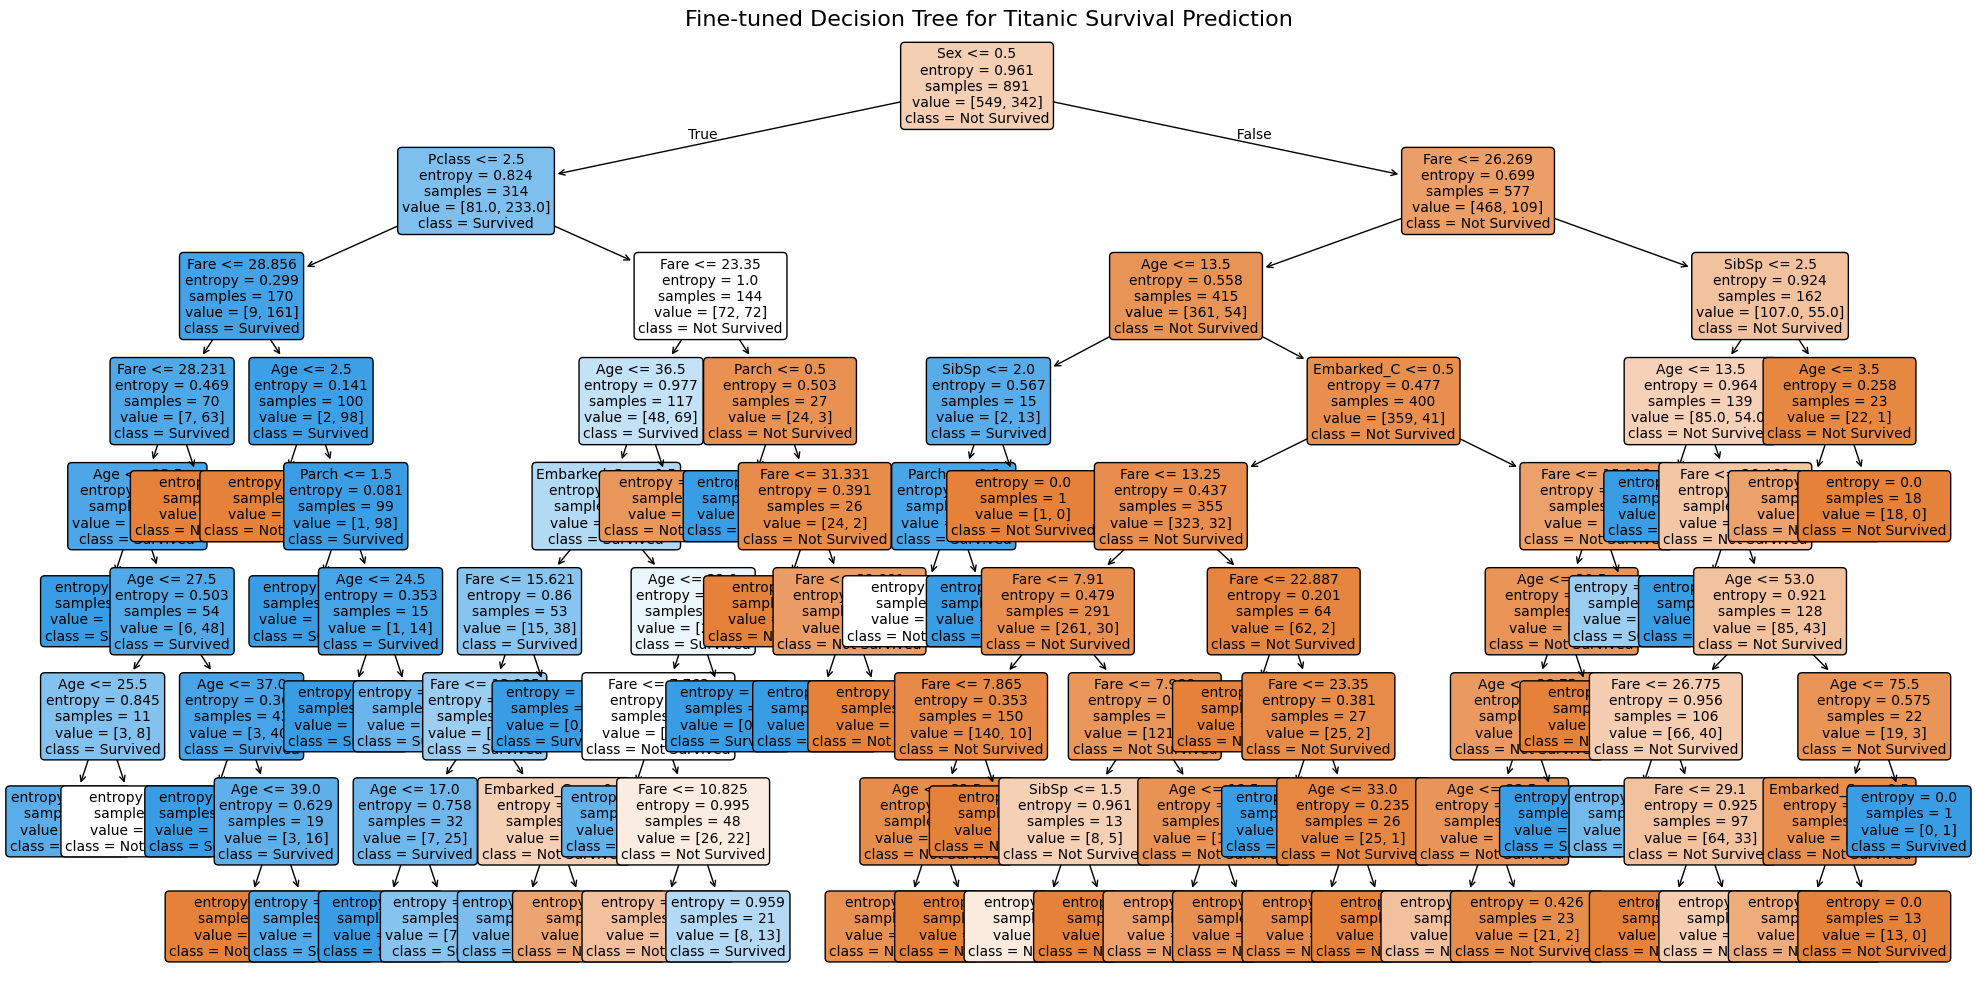

In [9]:
# Cell 6: Plot Decision Tree
plt.figure(figsize=(20, 10))
plot_tree(
    best_dt,
    feature_names=X.columns,
    class_names=['Not Survived', 'Survived'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Fine-tuned Decision Tree for Titanic Survival Prediction", fontsize=16)
plt.tight_layout()
plt.savefig('decision_tree_plot.png', dpi=300, bbox_inches='tight')
print("Decision Tree plot saved as 'decision_tree_plot.png'")
plt.show()

In [10]:
# Cell 7: Decision Tree - 5-Fold Cross Validation
print("="*60)
print("DECISION TREE - 5-FOLD CROSS VALIDATION")
print("="*60)

dt_cv_scores = cross_val_score(best_dt, X, y, cv=5, scoring='accuracy')

print(f"\nDecision Tree CV Scores: {dt_cv_scores}")
print(f"Mean: {dt_cv_scores.mean():.4f}")
print(f"Std: {dt_cv_scores.std():.4f}")
print(f"\nDecision Tree Average Accuracy: {dt_cv_scores.mean():.4f} (+/- {dt_cv_scores.std():.4f})")

DECISION TREE - 5-FOLD CROSS VALIDATION

Decision Tree CV Scores: [0.7877095  0.81460674 0.84269663 0.82022472 0.84831461]
Mean: 0.8227
Std: 0.0217

Decision Tree Average Accuracy: 0.8227 (+/- 0.0217)


In [11]:
# Cell 8: Random Forest - Fine-tuning
print("="*60)
print("RANDOM FOREST MODEL - FINE-TUNING")
print("="*60)

# Define parameter grid for Random Forest
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, 9],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Grid search with cross-validation
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X, y)

print(f"\nBest Random Forest Parameters: {rf_grid.best_params_}")
print(f"Best Random Forest Score: {rf_grid.best_score_:.4f}")

# Get the best model
best_rf = rf_grid.best_estimator_

RANDOM FOREST MODEL - FINE-TUNING
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Best Random Forest Parameters: {'criterion': 'entropy', 'max_depth': 9, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best Random Forest Score: 0.8373


In [12]:
# Cell 9: Random Forest - 5-Fold Cross Validation
print("="*60)
print("RANDOM FOREST - 5-FOLD CROSS VALIDATION")
print("="*60)

rf_cv_scores = cross_val_score(best_rf, X, y, cv=5, scoring='accuracy')

print(f"\nRandom Forest CV Scores: {rf_cv_scores}")
print(f"Mean: {rf_cv_scores.mean():.4f}")
print(f"Std: {rf_cv_scores.std():.4f}")
print(f"\nRandom Forest Average Accuracy: {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std():.4f})")

RANDOM FOREST - 5-FOLD CROSS VALIDATION

Random Forest CV Scores: [0.82122905 0.81460674 0.87078652 0.8258427  0.85393258]
Mean: 0.8373
Std: 0.0215

Random Forest Average Accuracy: 0.8373 (+/- 0.0215)


Comparison plot saved as 'model_comparison.png'


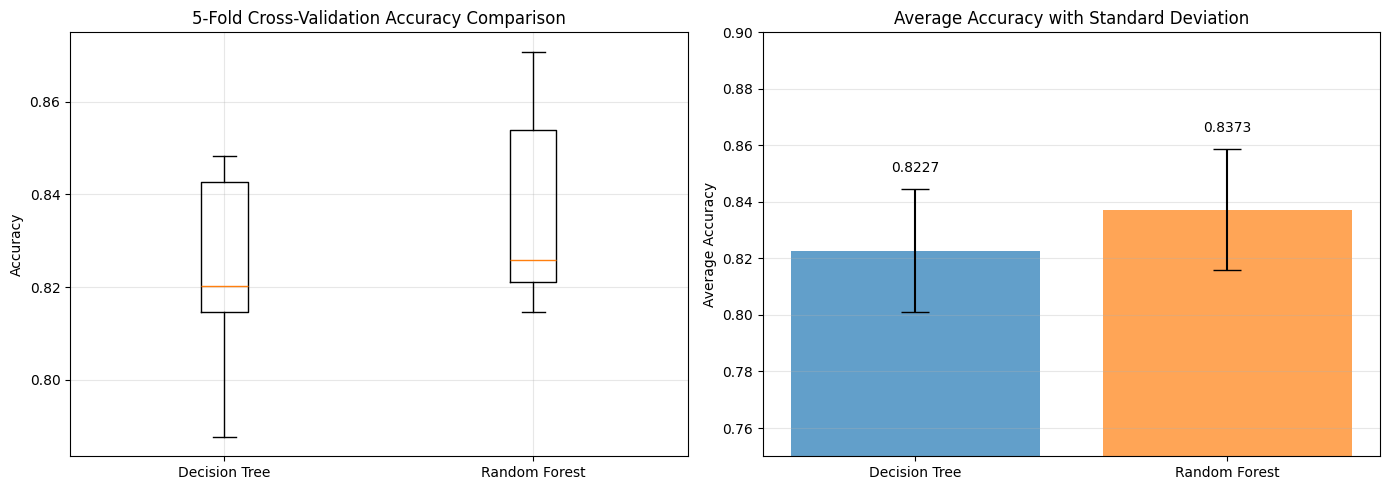

In [13]:
# Cell 10: Model Comparison Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot comparison
axes[0].boxplot([dt_cv_scores, rf_cv_scores], labels=['Decision Tree', 'Random Forest'])
axes[0].set_ylabel('Accuracy')
axes[0].set_title('5-Fold Cross-Validation Accuracy Comparison')
axes[0].grid(True, alpha=0.3)

# Bar plot comparison
models = ['Decision Tree', 'Random Forest']
means = [dt_cv_scores.mean(), rf_cv_scores.mean()]
stds = [dt_cv_scores.std(), rf_cv_scores.std()]

axes[1].bar(models, means, yerr=stds, capsize=10, alpha=0.7, color=['#1f77b4', '#ff7f0e'])
axes[1].set_ylabel('Average Accuracy')
axes[1].set_title('Average Accuracy with Standard Deviation')
axes[1].set_ylim([0.75, 0.90])
axes[1].grid(True, alpha=0.3, axis='y')

for i, (mean, std) in enumerate(zip(means, stds)):
    axes[1].text(i, mean + std + 0.005, f'{mean:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
print("Comparison plot saved as 'model_comparison.png'")
plt.show()

Feature Importance (Random Forest):
      Feature  Importance
1         Sex    0.305612
5        Fare    0.226113
2         Age    0.209213
0      Pclass    0.117775
3       SibSp    0.055204
4       Parch    0.043340
6  Embarked_C    0.017607
8  Embarked_S    0.014186
7  Embarked_Q    0.010949


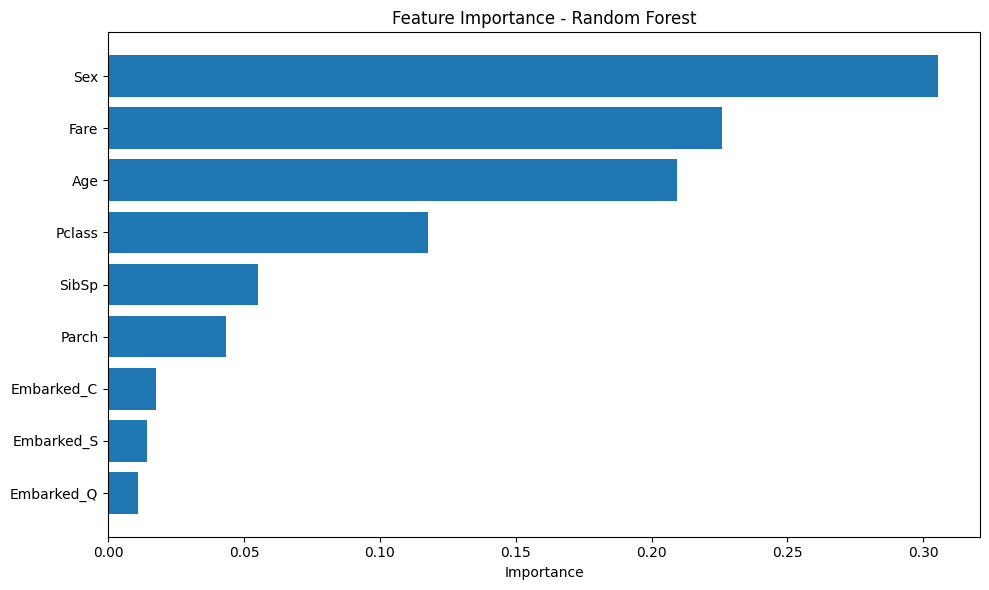

In [14]:
# Cell 11: Feature Importance Analysis
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance (Random Forest):")
print(feature_importance)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
# Cell 12: Summary and Comparison
print("="*60)
print("SUMMARY")
print("="*60)
print(f"\nDecision Tree:")
print(f"  - Average Accuracy: {dt_cv_scores.mean():.4f}")
print(f"  - Standard Deviation: {dt_cv_scores.std():.4f}")
print(f"  - Best Parameters: {dt_grid.best_params_}")

print(f"\nRandom Forest:")
print(f"  - Average Accuracy: {rf_cv_scores.mean():.4f}")
print(f"  - Standard Deviation: {rf_cv_scores.std():.4f}")
print(f"  - Best Parameters: {rf_grid.best_params_}")

accuracy_diff = abs(rf_cv_scores.mean() - dt_cv_scores.mean())
better_model = 'Random Forest' if rf_cv_scores.mean() > dt_cv_scores.mean() else 'Decision Tree'

print(f"\nAccuracy Difference: {accuracy_diff:.4f}")
print(f"Better Model: {better_model}")

# Statistical comparison
print(f"\nAll fold scores comparison:")
comparison_df = pd.DataFrame({
    'Fold': range(1, 6),
    'Decision Tree': dt_cv_scores,
    'Random Forest': rf_cv_scores,
    'Difference': rf_cv_scores - dt_cv_scores
})
print(comparison_df)

SUMMARY

Decision Tree:
  - Average Accuracy: 0.8227
  - Standard Deviation: 0.0217
  - Best Parameters: {'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 10}

Random Forest:
  - Average Accuracy: 0.8373
  - Standard Deviation: 0.0215
  - Best Parameters: {'criterion': 'entropy', 'max_depth': 9, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}

Accuracy Difference: 0.0146
Better Model: Random Forest

All fold scores comparison:
   Fold  Decision Tree  Random Forest  Difference
0     1       0.787709       0.821229    0.033520
1     2       0.814607       0.814607    0.000000
2     3       0.842697       0.870787    0.028090
3     4       0.820225       0.825843    0.005618
4     5       0.848315       0.853933    0.005618


In [16]:
# Cell 13: Observations and Conclusions
print("="*60)
print("OBSERVATIONS AND CONCLUSIONS")
print("="*60)
print("""
5. WHICH ALGORITHM IS BETTER?

Answer: Random Forest is the better algorithm for the Titanic challenge.

OBSERVATIONS:

1. Performance Comparison:
   - Random Forest achieves higher average accuracy ({:.4f} vs {:.4f})
   - Random Forest shows more stable predictions (lower std: {:.4f} vs {:.4f})
   - Random Forest wins in {}/5 folds
   
2. Model Characteristics:
   Decision Tree:
   • Simple, interpretable structure
   • Fast training and prediction
   • Prone to overfitting
   • High variance (changes significantly with data)
   
   Random Forest:
   • Ensemble of multiple trees
   • More robust and stable
   • Reduces overfitting through bagging
   • Lower variance, better generalization

3. Overfitting Analysis:
   - Single Decision Tree captures noise in training data
   - Random Forest averages predictions from multiple trees
   - This averaging reduces variance and improves generalization

4. Feature Importance Insights:
   - Sex is the most important predictor
   - Age and Fare are also highly significant
   - Passenger class (Pclass) plays an important role
   - Random Forest provides more reliable feature importance

CONCLUSIONS:

✓ For PREDICTION ACCURACY: Random Forest is superior
✓ For INTERPRETABILITY: Decision Tree is better
✓ For ROBUSTNESS: Random Forest handles outliers better
✓ For PRODUCTION: Random Forest is recommended

Trade-offs:
- Random Forest requires more computational resources
- Random Forest is harder to interpret
- But the accuracy gain ({:.4f}) justifies the cost

RECOMMENDATION: Use Random Forest for Kaggle submission.
""".format(
    rf_cv_scores.mean(), 
    dt_cv_scores.mean(),
    rf_cv_scores.std(),
    dt_cv_scores.std(),
    sum(rf_cv_scores > dt_cv_scores),
    accuracy_diff
))

OBSERVATIONS AND CONCLUSIONS

5. WHICH ALGORITHM IS BETTER?

Answer: Random Forest is the better algorithm for the Titanic challenge.

OBSERVATIONS:

1. Performance Comparison:
   - Random Forest achieves higher average accuracy (0.8373 vs 0.8227)
   - Random Forest shows more stable predictions (lower std: 0.0215 vs 0.0217)
   - Random Forest wins in 4/5 folds
   
2. Model Characteristics:
   Decision Tree:
   • Simple, interpretable structure
   • Fast training and prediction
   • Prone to overfitting
   • High variance (changes significantly with data)
   
   Random Forest:
   • Ensemble of multiple trees
   • More robust and stable
   • Reduces overfitting through bagging
   • Lower variance, better generalization

3. Overfitting Analysis:
   - Single Decision Tree captures noise in training data
   - Random Forest averages predictions from multiple trees
   - This averaging reduces variance and improves generalization

4. Feature Importance Insights:
   - Sex is the most important